# Labrador Sea seasonal-mean maps — CESM3 preindustrial development

Compares CAM h0a monthly output for:
* **388** — `b.e30_alpha09e_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3.388` — Lab Sea stays frozen
* **377** — `b.e30_alpha09d_m.B1850C_MTso_Gris_Marbl.ne30_t233_wgx3.377` — Lab Sea melts

Both start from the same slightly frozen state.  Analysis window per run is set by `CASE_YEARS` (atm) and `CASE_YEARS_MOM` (ocean) in the config cell below.

Produces side-by-side maps of the two cases for the following fields, averaged over **JFM** and **JAS**:

Atm (CAM h0a) fields:
* `ICEFRAC` — sea-ice fraction
* `SHFLX`, `LHFLX` — sensible / latent heat flux (up)
* `TS` — surface temperature
* `PRECT` — total precipitation (GPCP obs overlaid as a third panel)
* `CLDLOW` — low cloud fraction
* `FSNS`, `FLNS`, `FSDS` — net-solar, net-longwave, downwelling-solar at surface
* `RESSURF` — **derived** net downward surface energy flux = `FSNS − FLNS − SHFLX − LHFLX`

Ocean (MOM6 sfc) fields:
* `MLD` — ocean mixed-layer depth (`mlotst`, σ_T definition, daily → monthly-averaged, plotted on the MOM6 curvilinear grid)

All logic lives in `labsea_utils.py` — this notebook is just orchestration.

In [20]:
%load_ext autoreload
%autoreload 2

import importlib
import labsea_utils as lsu
importlib.reload(lsu)

import matplotlib.pyplot as plt
from dask.distributed import Client
from dask_jobqueue import PBSCluster

RUNS   = ["388", "377"]
# Fields to plot — start from the module's VAR_LIST so any new entry there
# (e.g. RESSURF) is picked up automatically.  Override this list explicitly if
# you want to restrict the notebook to a subset for a fast run.
VARS   = list(lsu.VAR_LIST)     # ICEFRAC, SHFLX, LHFLX, TS, PRECT, CLDLOW,
                                # FSNS, FLNS, FSDS, RESSURF
SEASONS = ["JFM", "JAS"]
FIG_DIR = "./figs"

# ── Per-case year ranges ───────────────────────────────────────────────────
# Set an explicit (y0, y1) for each run to restrict the analysis window.
# Set an entry to None to use the run's full available record.
# Both runs share years 1-40, so a common overlap window is the default.
CASE_YEARS = {
    "388": (6, 40),   # skip first 5 yrs as spin-up, use through year 40
    "377": (6, 40),
}

# MOM/MLD variables get their own list; edit CASE_YEARS_MOM if you want a
# different window for the ocean (e.g. shorter — daily files are heavy).
MOM_VARS       = list(lsu.MOM_VAR_LIST)   # ['MLD']
CASE_YEARS_MOM = {
    "388": (6, 40),
    "377": (6, 40),
}

for r in RUNS:
    y = CASE_YEARS.get(r)
    print(f"  atm run {r}: year range = {y}")
print("Variables:", VARS)
print("MOM vars :", MOM_VARS)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  atm run 388: year range = (6, 40)
  atm run 377: year range = (6, 40)
Variables: ['ICEFRAC', 'SHFLX', 'LHFLX', 'TS', 'PRECT', 'CLDLOW', 'FSNS', 'FLNS', 'FSDS', 'RESSURF']
MOM vars : ['MLD']


In [21]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",   
    cores=4,
    memory="32GB",
    processes=4,      # one process per core (safe default)cesm2
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs"
)

cluster.scale(jobs=32)
client = Client(cluster)

client

/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37715 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc68.hpc.ucar.edu/44860/proxy/37715/status,
Dashboard: /node/crhtc68.hpc.ucar.edu/44860/proxy/37715/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.176:38939,Workers: 0
Dashboard: /node/crhtc68.hpc.ucar.edu/44860/proxy/37715/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [22]:
# Open the atm h0a datasets — each run uses its own CASE_YEARS window.
datasets = {}
for r in RUNS:
    yrs = CASE_YEARS.get(r)
    print(f"Opening atm run {r}  year_range={yrs} ...")
    datasets[r] = lsu.load_run(r, VARS, year_range=yrs)
    print(f"  {r}: {datasets[r].sizes.get('time', '?')} monthly records")

Opening atm run 388  year_range=(6, 40) ...
  388: 420 monthly records
Opening atm run 377  year_range=(6, 40) ...
  377: 420 monthly records


In [23]:
# Compute (var, season) -> {run_id: 2D field} climatologies (atm side).
clim = {}
for var in VARS:
    for season in SEASONS:
        fields = {}
        for r in RUNS:
            fields[r] = lsu.seasonal_mean(datasets[r], var, season,
                                          year_range=CASE_YEARS.get(r))
            fields[r].load()
        clim[(var, season)] = fields
        print(f"  computed {var:8s} {season}")

# GPCP overlay for PRECT.  Full record, treated as a third panel.
gpcp = lsu.load_gpcp()
for season in SEASONS:
    obs_field = lsu.obs_seasonal_mean(gpcp, "PRECT", season).load()
    clim[("PRECT", season)]["GPCP"] = obs_field
    print(f"  added GPCP PRECT {season}")

  computed ICEFRAC  JFM
  computed ICEFRAC  JAS
  computed SHFLX    JFM
  computed SHFLX    JAS
  computed LHFLX    JFM
  computed LHFLX    JAS
  computed TS       JFM
  computed TS       JAS
  computed PRECT    JFM
  computed PRECT    JAS
  computed CLDLOW   JFM
  computed CLDLOW   JAS
  computed FSNS     JFM
  computed FSNS     JAS
  computed FLNS     JFM
  computed FLNS     JAS
  computed FSDS     JFM
  computed FSDS     JAS
  computed RESSURF  JFM
  computed RESSURF  JAS
  added GPCP PRECT JFM
  added GPCP PRECT JAS


  saved ./figs/map_ICEFRAC_JFM_LabSea.png


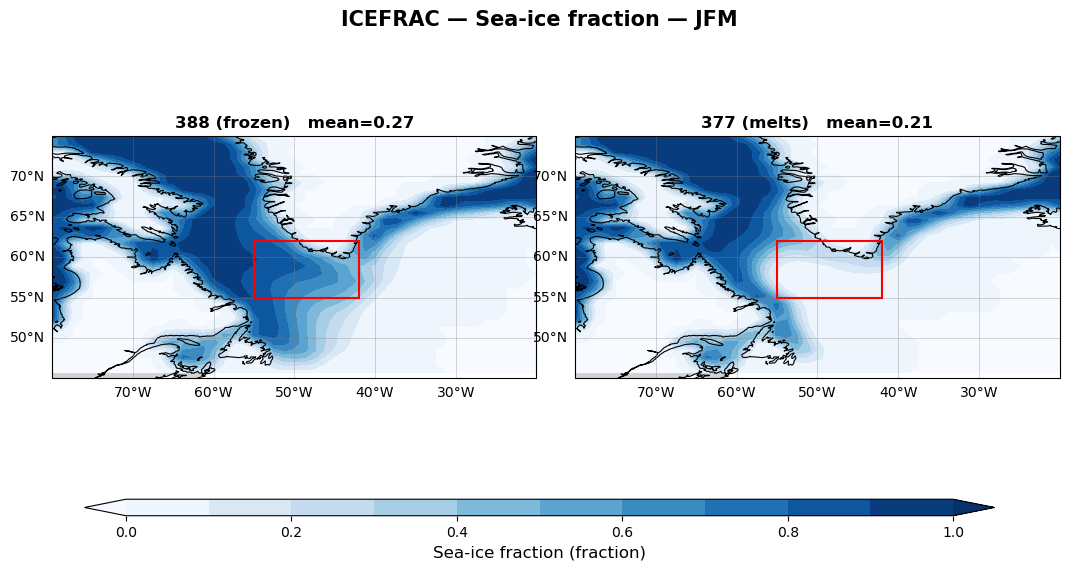

  saved ./figs/map_ICEFRAC_JAS_LabSea.png


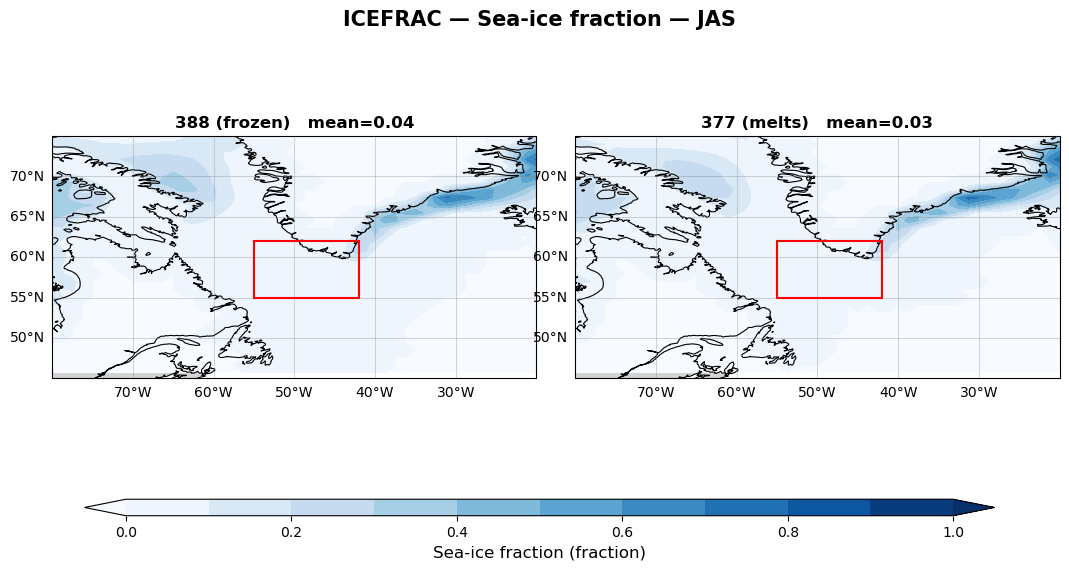

  saved ./figs/map_SHFLX_JFM_LabSea.png


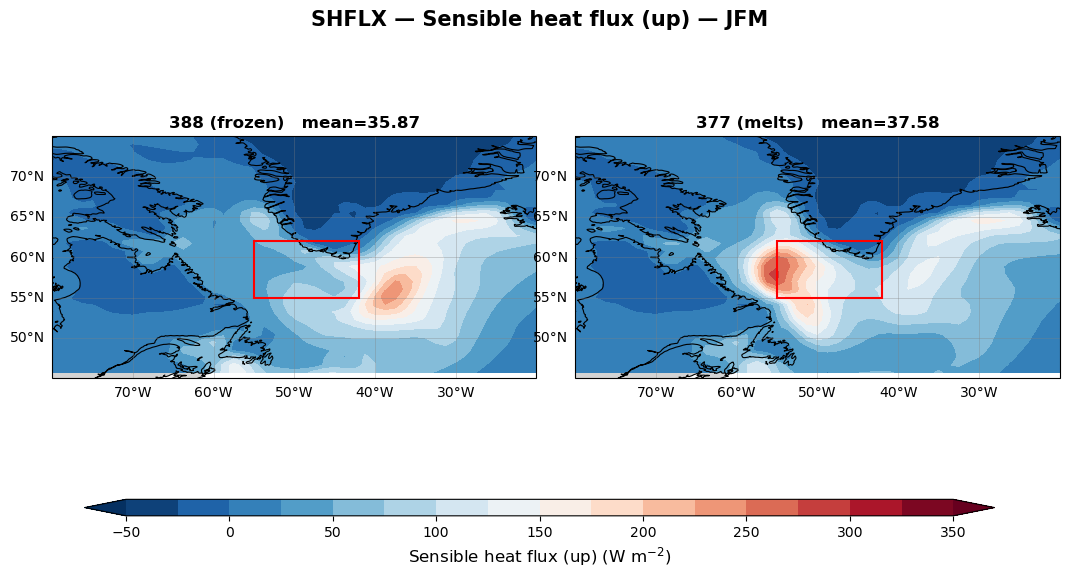

  saved ./figs/map_SHFLX_JAS_LabSea.png


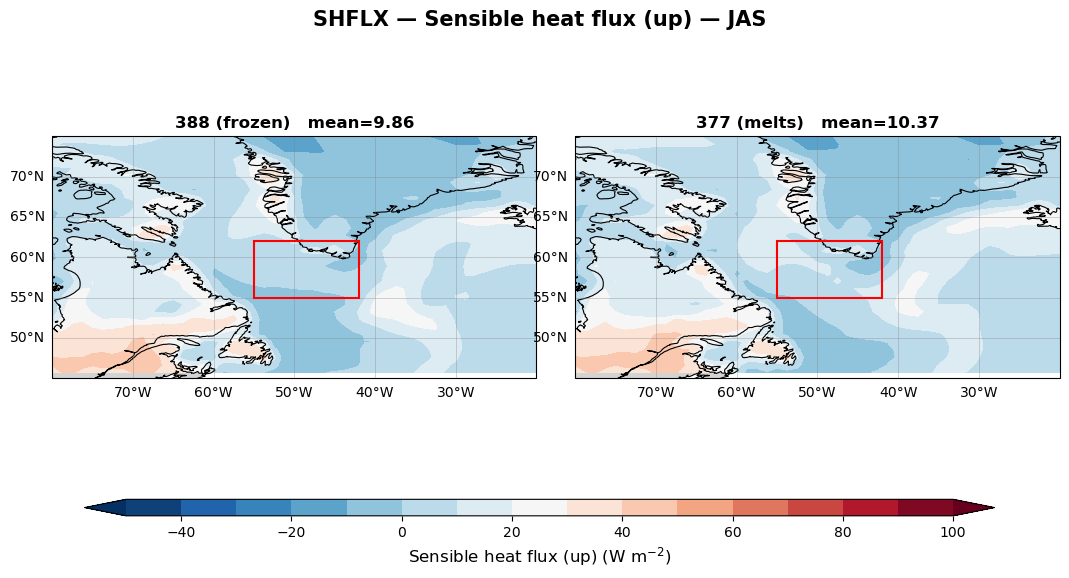

  saved ./figs/map_LHFLX_JFM_LabSea.png


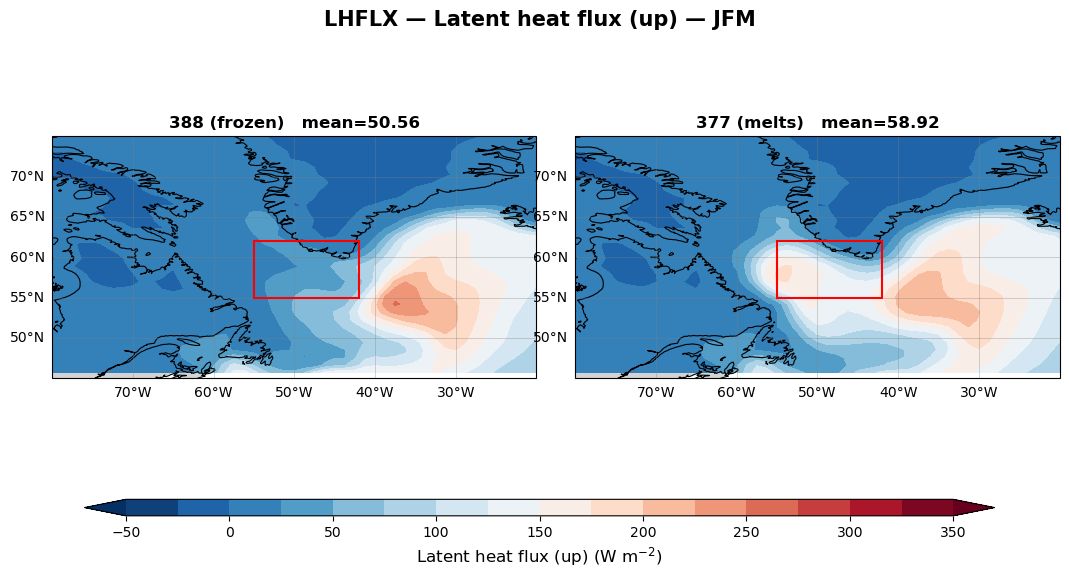

  saved ./figs/map_LHFLX_JAS_LabSea.png


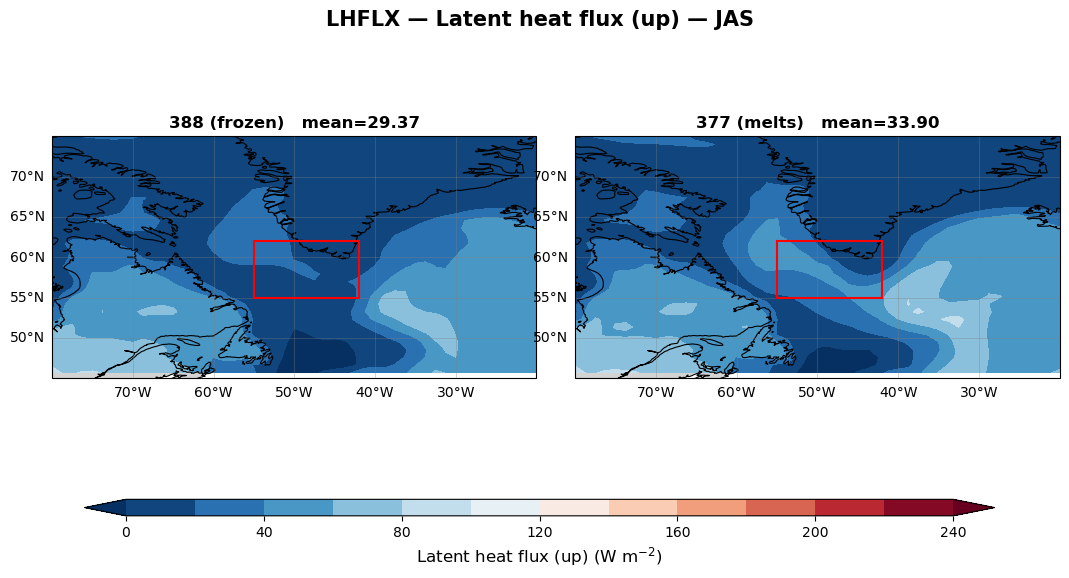

  saved ./figs/map_TS_JFM_LabSea.png


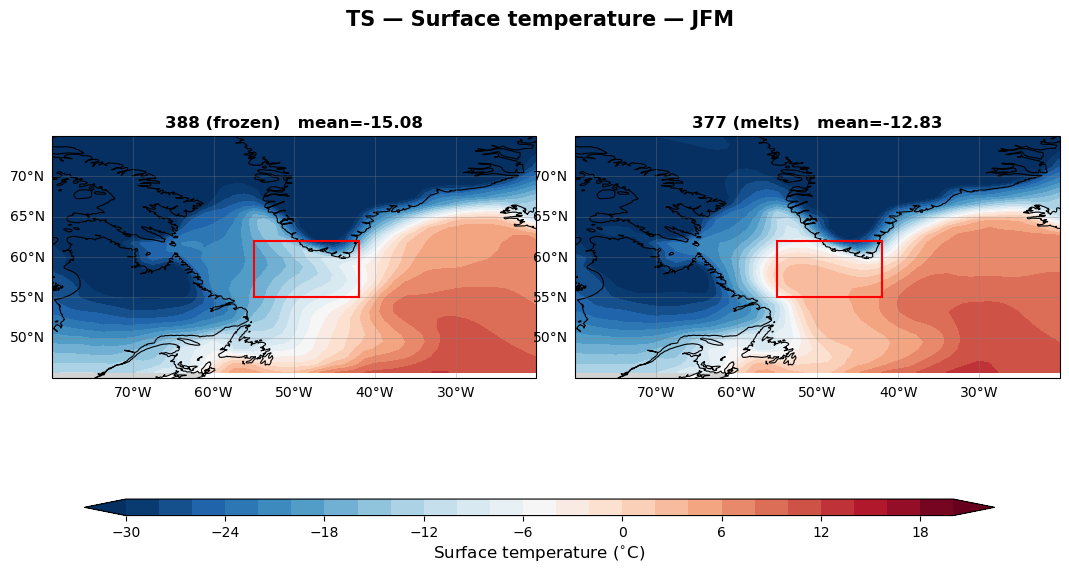

  saved ./figs/map_TS_JAS_LabSea.png


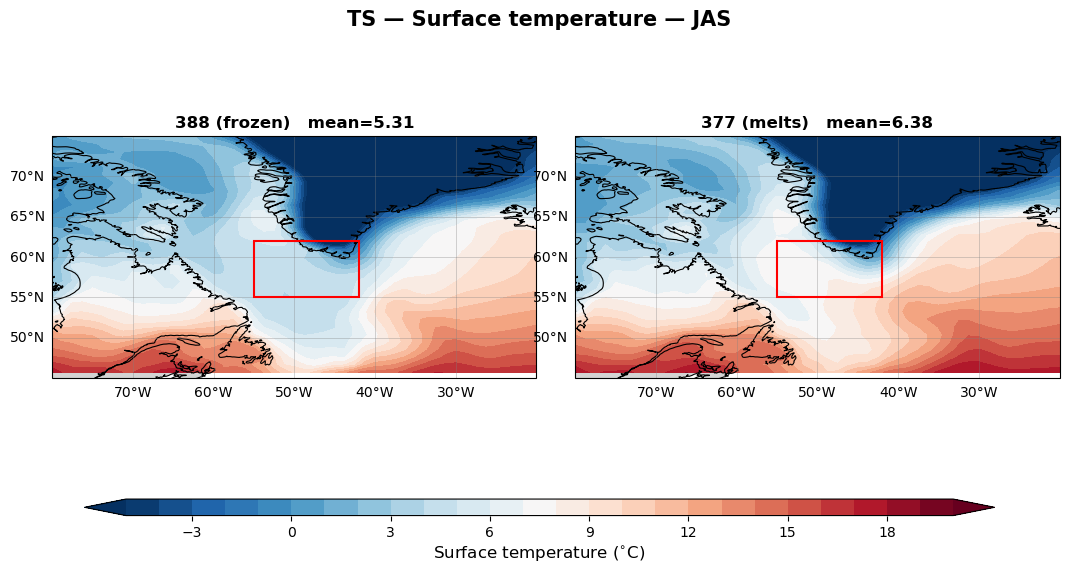

  saved ./figs/map_PRECT_JFM_LabSea.png


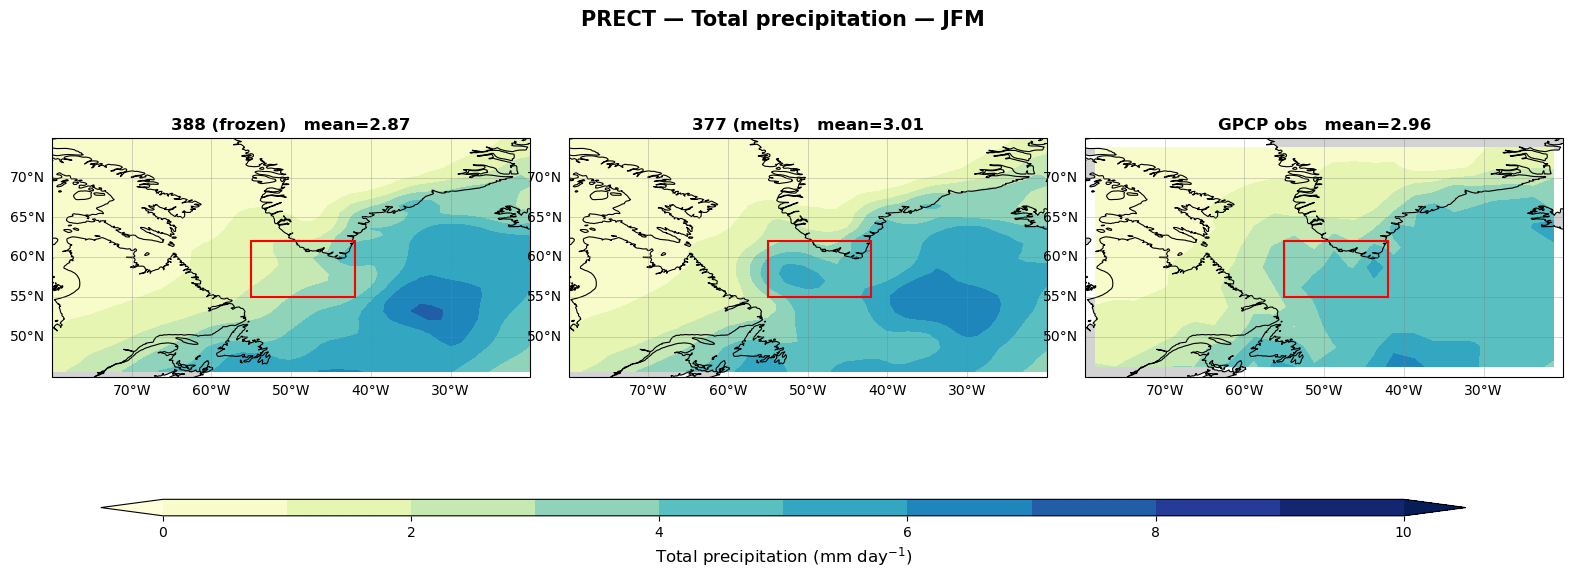

  saved ./figs/map_PRECT_JAS_LabSea.png


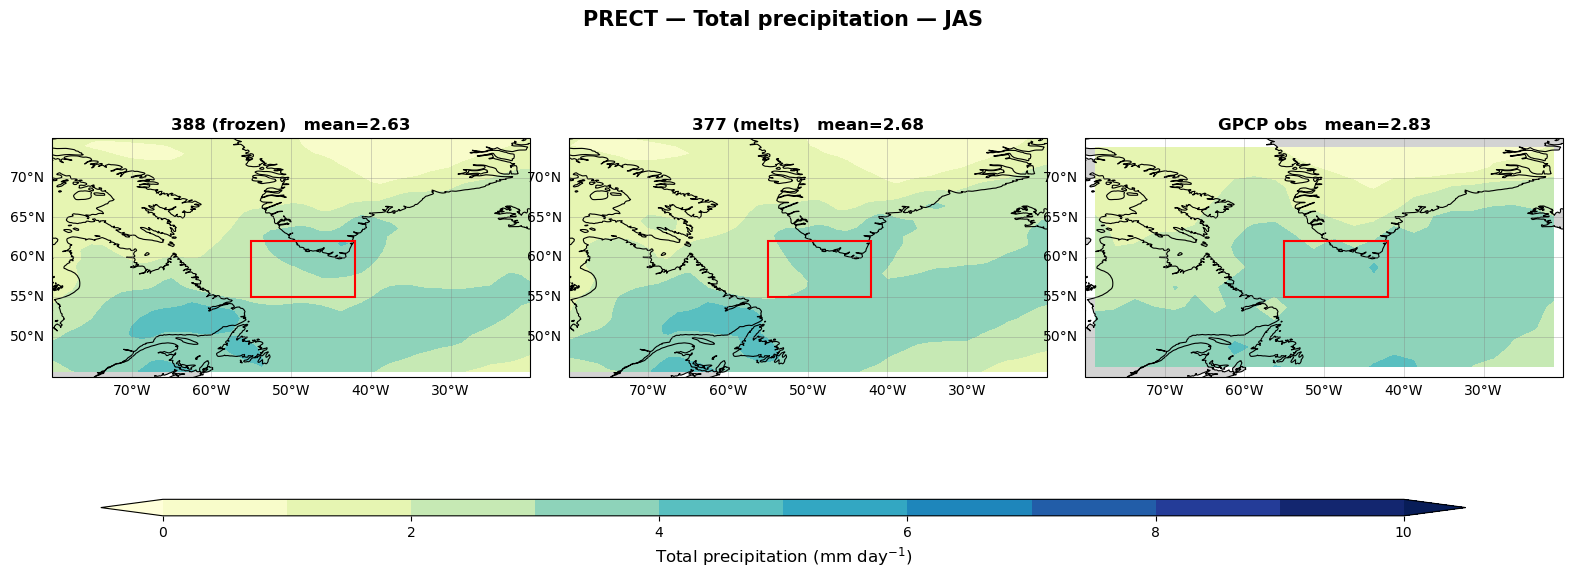

  saved ./figs/map_CLDLOW_JFM_LabSea.png


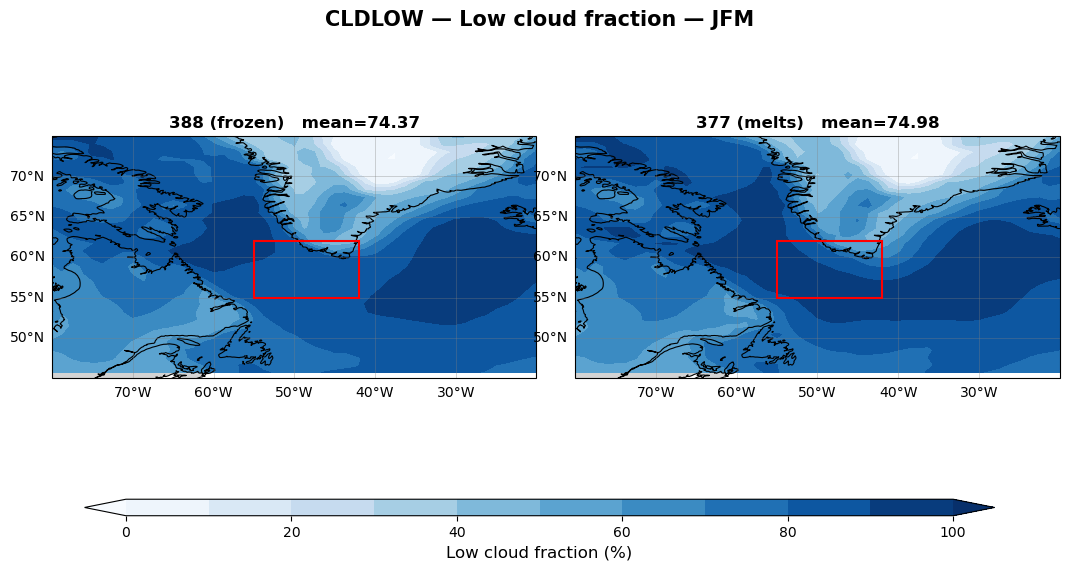

  saved ./figs/map_CLDLOW_JAS_LabSea.png


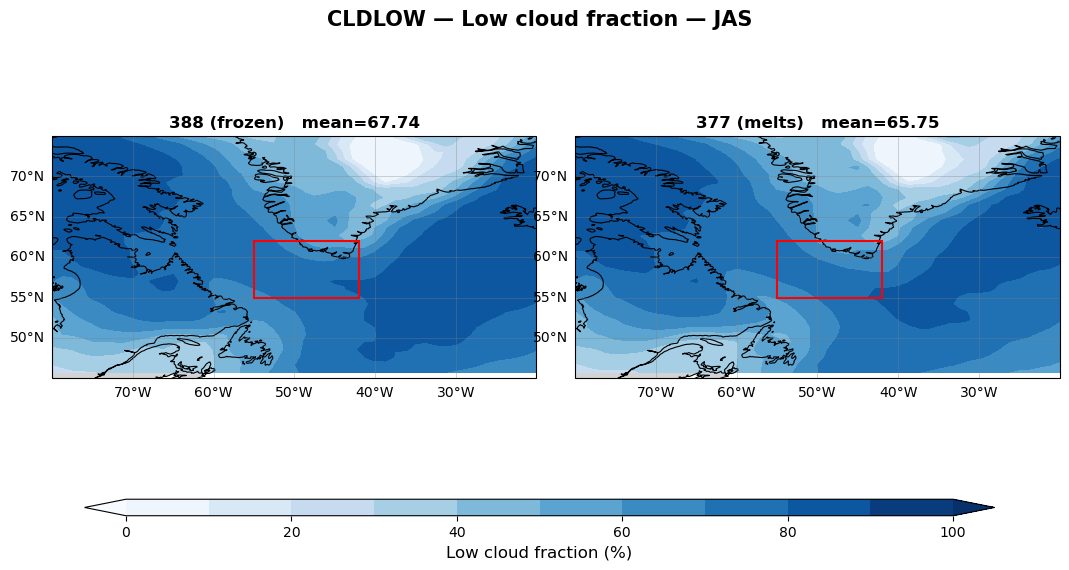

  saved ./figs/map_FSNS_JFM_LabSea.png


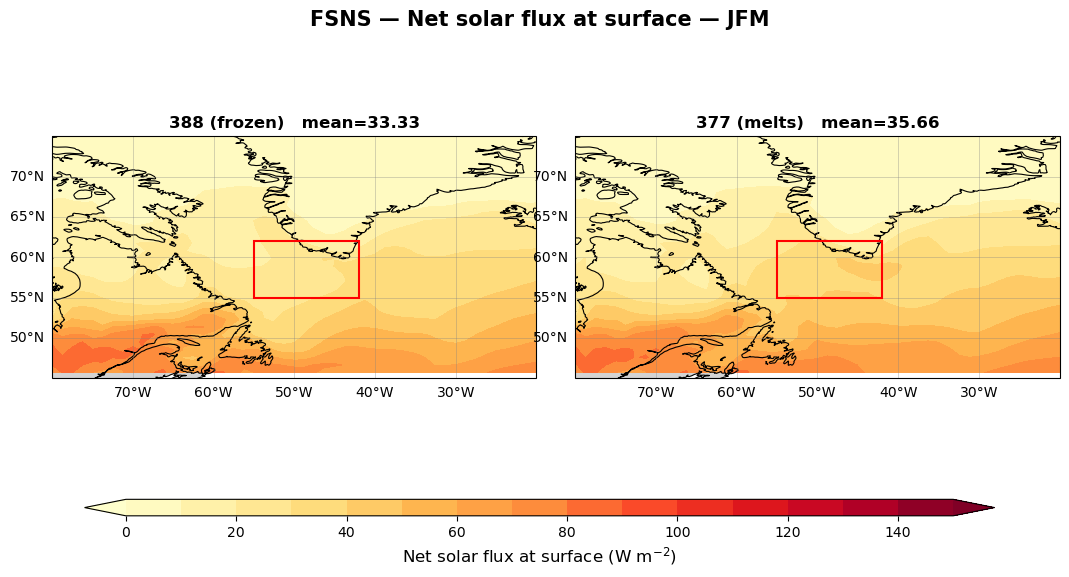

  saved ./figs/map_FSNS_JAS_LabSea.png


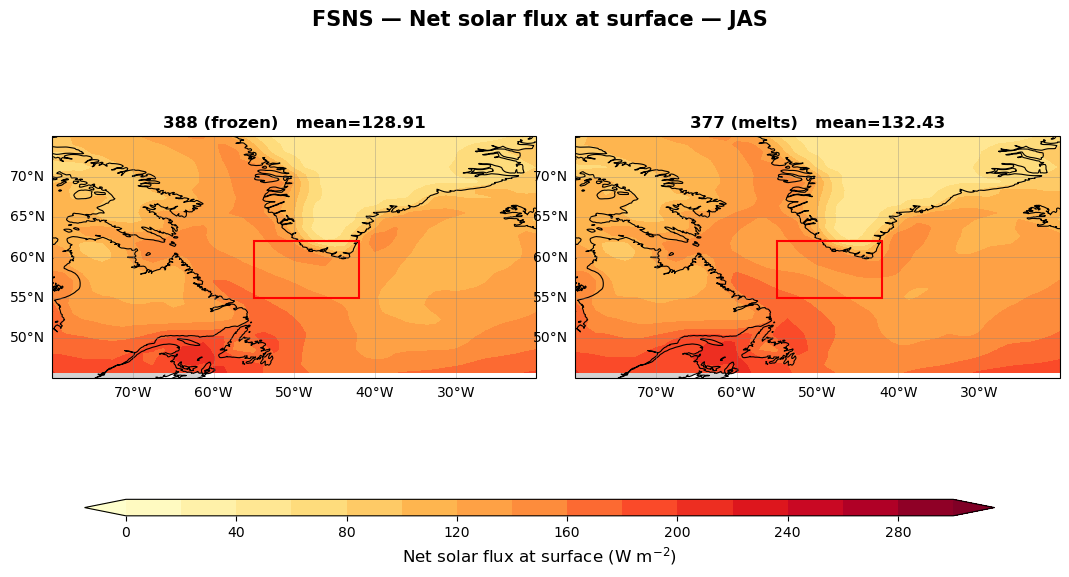

  saved ./figs/map_FLNS_JFM_LabSea.png


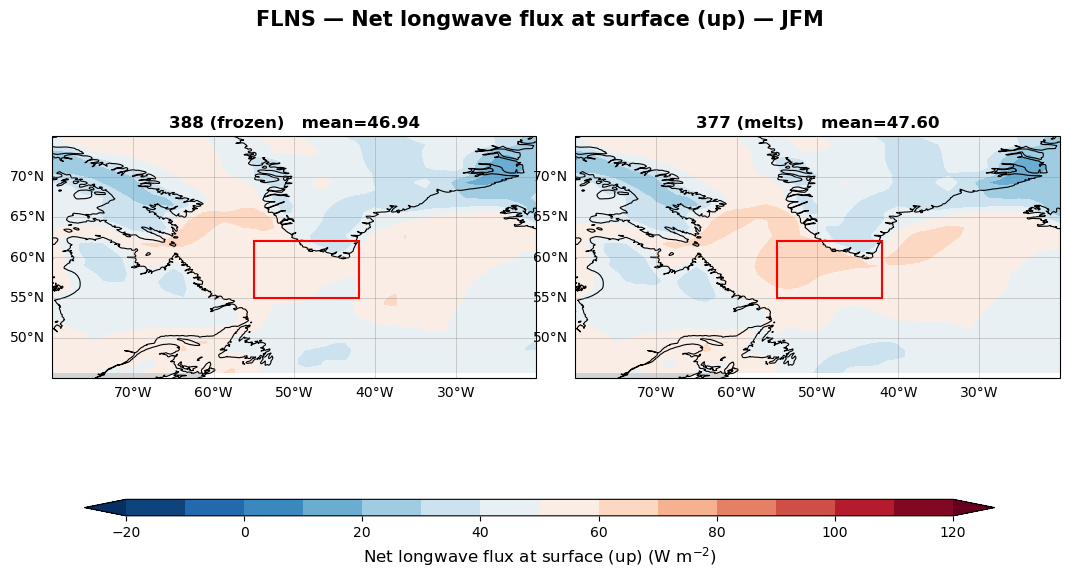

  saved ./figs/map_FLNS_JAS_LabSea.png


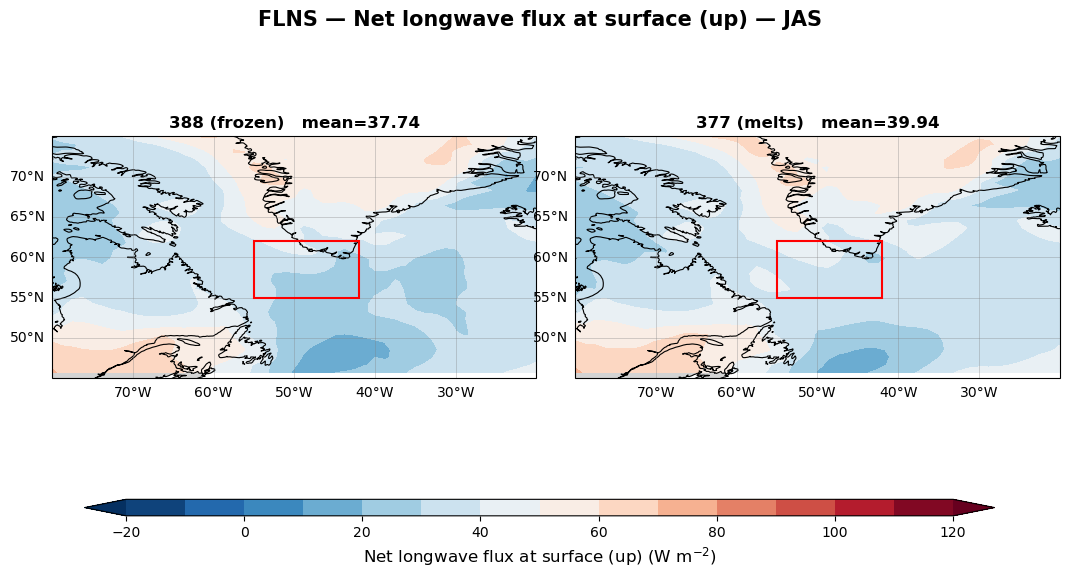

  saved ./figs/map_FSDS_JFM_LabSea.png


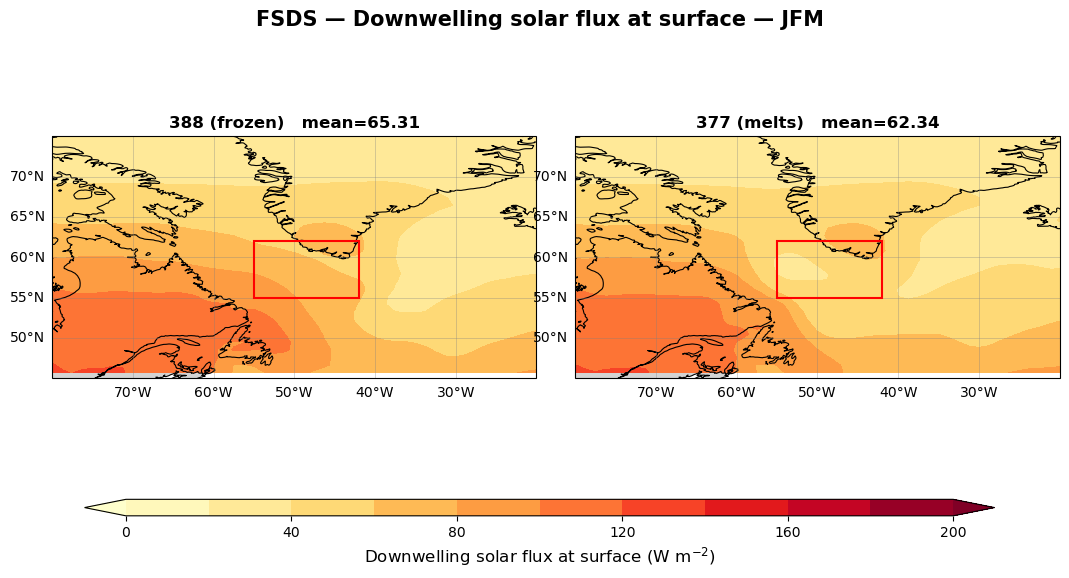

  saved ./figs/map_FSDS_JAS_LabSea.png


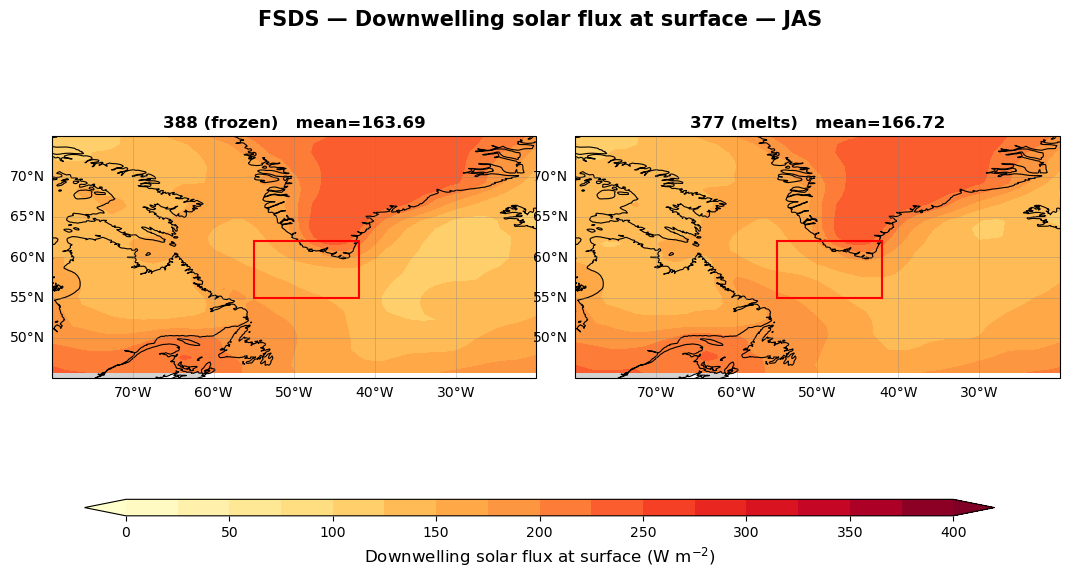

  saved ./figs/map_RESSURF_JFM_LabSea.png


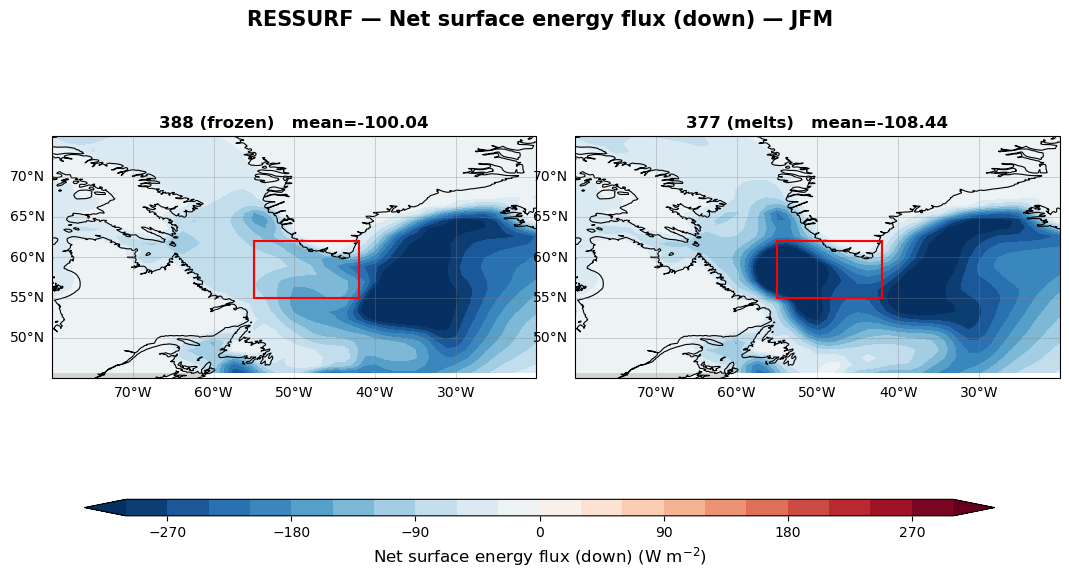

  saved ./figs/map_RESSURF_JAS_LabSea.png


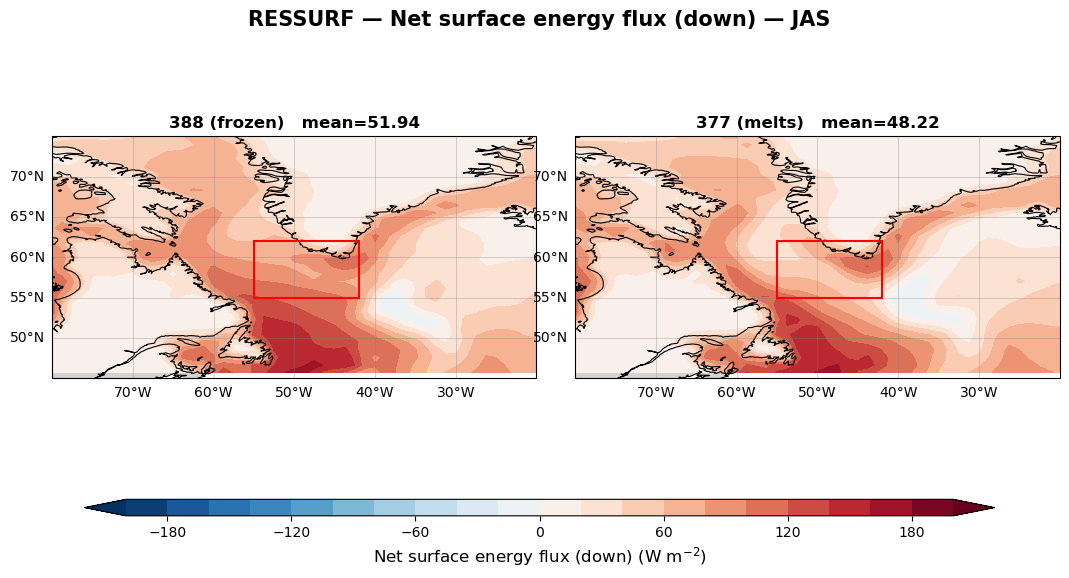

In [24]:
# Side-by-side maps, one figure per (variable, season).
# Red box overlays the SE Labrador Sea box used for the timeseries.
for var in VARS:
    for season in SEASONS:
        lsu.plot_pair_map(clim[(var, season)], var, season,
                          region="LabSea",
                          extra_box="LabSea_SE",
                          save_dir=FIG_DIR)
        plt.show()

## Ocean fields (MOM) — mixed-layer depth
The MOM `sfc` stream carries daily MLD (`mlotst`).  The utility opens the daily
files, aggregates them to monthly means on the fly, and attaches the static
grid (geolat, geolon, wet mask, cell area) so plotting/regional means work on
the curvilinear grid.

Opening MOM run 388  year_range=(6, 40) ...
  388: 420 monthly records
Opening MOM run 377  year_range=(6, 40) ...
  377: 420 monthly records
  computed MLD      JFM
  computed MLD      JAS
[  25   50  100  200  400  600  800 1200 1600 2000 2500]
  saved ./figs/map_MLD_JFM_LabSea.png


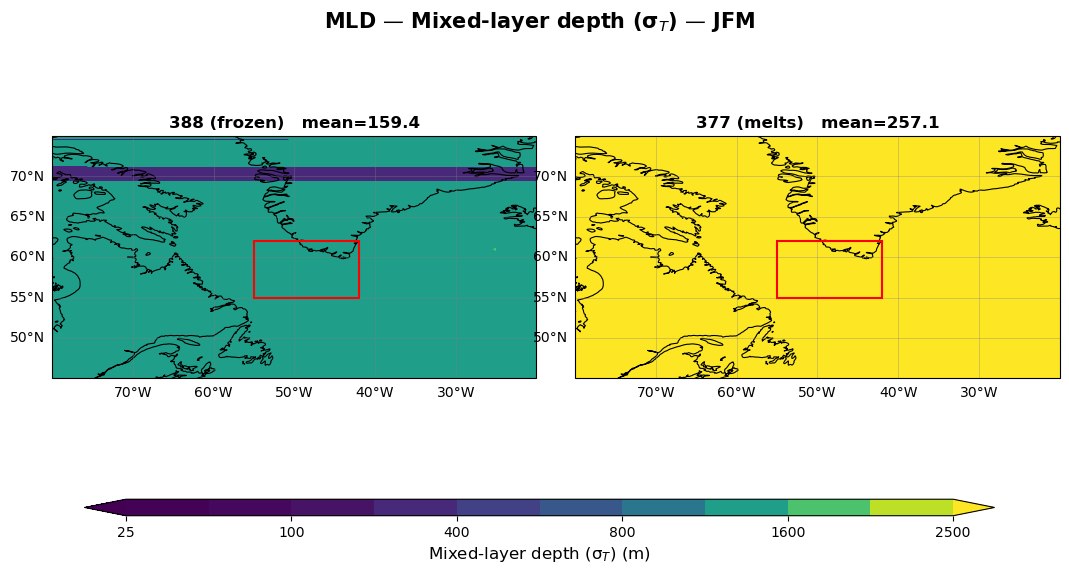

[ 10  20  30  40  60  80 100 150 200 300 400]
  saved ./figs/map_MLD_JAS_LabSea.png


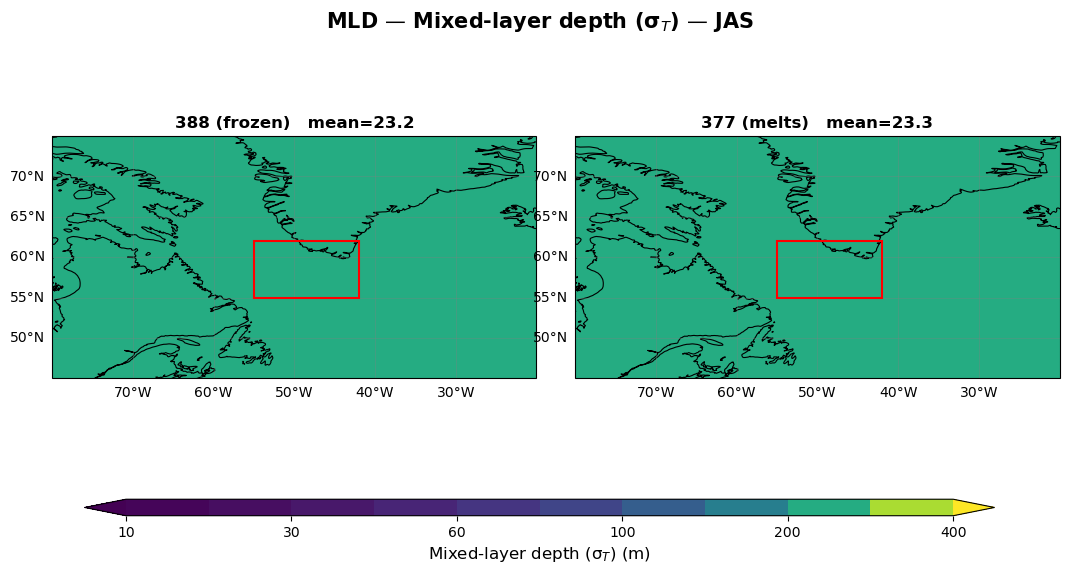

In [26]:
# Open MOM datasets (daily sfc stream → monthly means with static grid).
mom_datasets = {}
for r in RUNS:
    yrs = CASE_YEARS_MOM.get(r)
    print(f"Opening MOM run {r}  year_range={yrs} ...")
    mom_datasets[r] = lsu.load_run_mom(r, mom_vars=MOM_VARS, year_range=yrs)
    print(f"  {r}: {mom_datasets[r].sizes['time']} monthly records")

# Compute (mom_var, season) -> {run_id: 2D field}.
clim_mom = {}
for var in MOM_VARS:
    for season in SEASONS:
        fields = {}
        for r in RUNS:
            fields[r] = lsu.mom_seasonal_mean(mom_datasets[r], var, season,
                                              year_range=CASE_YEARS_MOM.get(r))
            fields[r].load()
        clim_mom[(var, season)] = fields
        print(f"  computed {var:8s} {season}")

# Side-by-side maps for each MOM variable × season.
for var in MOM_VARS:
    for season in SEASONS:
        lsu.plot_pair_map_mom(clim_mom[(var, season)], var, season,
                              region="LabSea",
                              extra_box="LabSea_SE",
                              save_dir=FIG_DIR)
        plt.show()

The red rectangle marks the **SE Labrador Sea** box (`REGIONS['LabSea_SE']`) that the companion notebook uses for the seasonal timeseries.  Adjust its bounds in `labsea_utils.py` if it doesn't line up with the region of frozen surface in 388.